# Descargar el Marco Geoestadístico 2020 (INEGI) → `data/raw/INEGI/mg_2020/`

Baja el **Marco Geoestadístico. Censo de Población y Vivienda 2020**
(edición integrada nacional, ficha INEGI `upc=889463807469`, zip de feb-2021),
verifica tamaño y hash, extrae sólo las capas que usa el atlas y deja un
`SOURCE.md` con la procedencia. Es el paso S1 de `docs/planes/03-capas-inegi-medi.md`.

Capas extraídas (shapefiles en `conjunto_de_datos/`):

| archivo | capa | uso en el atlas |
|---|---|---|
| `00a`   | AGEB urbana (63 982) y rural (17 469) | capa MEDI a nivel AGEB |
| `00mun` | Municipios (2 469)            | agregado municipal |
| `00ent` | Entidades federativas (32)    | contexto / etiquetas |

El zip completo se conserva junto a lo extraído (es la evidencia de
procedencia; su hash queda en `SOURCE.md`). Reejecutar la libreta es
idempotente: no vuelve a bajar si el zip está completo ni a extraer si las
capas ya existen.

In [1]:
import hashlib
import re
import urllib.request
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import geopandas as gpd

ROOT = Path("..").resolve()                      # repo (libreta en notebooks/)
MGN_DIR = ROOT / "data" / "raw" / "INEGI" / "mg_2020"
ZIP = MGN_DIR / "mg_2020_integrado.zip"

UPC = "889463807469"
FICHA = f"https://www.inegi.org.mx/app/biblioteca/ficha.html?upc={UPC}"
URL = (
    "https://www.inegi.org.mx/contenidos/productos/prod_serv/contenidos/espanol/"
    f"bvinegi/productos/geografia/marcogeo/{UPC}/mg_2020_integrado.zip"
)
# Content-Length observado el 2026-09-02 (Last-Modified: 2021-02-15). Si INEGI
# republica el zip, el chequeo de tamaño fallará a propósito para que se revise.
EXPECTED_SIZE = 257_527_530

LAYERS = {"00a": "AGEB urbana", "00mun": "Municipios", "00ent": "Entidades federativas"}
SIDECARS = ("shp", "shx", "dbf", "prj", "cpg")
# Además de las capas, se extraen los catálogos ligeros (txt/csv) del zip.
EXTRA = re.compile(r"^catalogos/.*\.(txt|csv)$")

MGN_DIR.mkdir(parents=True, exist_ok=True)

## 1. Descarga (reanudable)

Si existe un zip parcial se pide el resto con `Range`; si ya está completo no
se toca. INEGI sirve el archivo con `Content-Length`, así que el tamaño es
la primera verificación.

In [2]:
def remote_size(url: str) -> int:
    req = urllib.request.Request(url, method="HEAD")
    with urllib.request.urlopen(req, timeout=60) as r:
        return int(r.headers["Content-Length"])


def download(url: str, dest: Path, expected: int, chunk: int = 1 << 20) -> None:
    have = dest.stat().st_size if dest.exists() else 0
    if have == expected:
        print(f"{dest.name}: ya completo ({have/1e6:.1f} MB)")
        return
    if have > expected:
        raise RuntimeError(f"{dest} es mayor que lo esperado ({have} > {expected}); bórralo y reintenta")
    headers = {"Range": f"bytes={have}-"} if have else {}
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "ab" if have else "wb") as f:
        if have and r.status != 206:
            raise RuntimeError("El servidor no aceptó reanudar; borra el parcial y reintenta")
        done = have
        while True:
            b = r.read(chunk)
            if not b:
                break
            f.write(b)
            done += len(b)
            if done % (20 << 20) < chunk:  # cada ~20 MB
                print(f"  {done/1e6:7.1f} / {expected/1e6:.1f} MB", end="\r")
    print(f"\n{dest.name}: descargado ({dest.stat().st_size/1e6:.1f} MB)")


size_now = remote_size(URL)
if size_now != EXPECTED_SIZE:
    raise RuntimeError(
        f"INEGI reporta {size_now} bytes y la libreta espera {EXPECTED_SIZE}. "
        "Probablemente republicaron el marco: revisa la ficha y actualiza EXPECTED_SIZE."
    )
download(URL, ZIP, EXPECTED_SIZE)
assert ZIP.stat().st_size == EXPECTED_SIZE

mg_2020_integrado.zip: ya completo (257.5 MB)


## 2. Hash y contenido del zip

In [3]:
def sha256(path: Path, chunk: int = 1 << 20) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while b := f.read(chunk):
            h.update(b)
    return h.hexdigest()


ZIP_SHA256 = sha256(ZIP)
print("sha256:", ZIP_SHA256)

with zipfile.ZipFile(ZIP) as z:
    members = z.namelist()
print(f"{len(members)} miembros; carpetas:", sorted({m.split('/')[0] for m in members if '/' in m}))

sha256: 98ccee5e796da1e00a3c6fa3d7d821d16b8cc407a16d782f9ce0d072b9dfcac7
50 miembros; carpetas: ['catalogos', 'conjunto_de_datos', 'metadatos']


## 3. Extraer sólo lo que usa el atlas

In [4]:
wanted = [
    f"conjunto_de_datos/{layer}.{ext}" for layer in LAYERS for ext in SIDECARS
] + [m for m in members if EXTRA.match(m)]

faltan = [m for m in wanted if m not in members]
assert not faltan, f"El zip no trae: {faltan}"

extraidos, omitidos = [], []
with zipfile.ZipFile(ZIP) as z:
    for m in wanted:
        dest = MGN_DIR / m
        info = z.getinfo(m)
        if dest.exists() and dest.stat().st_size == info.file_size:
            omitidos.append(m)
            continue
        z.extract(m, MGN_DIR)
        extraidos.append(m)
print(f"extraídos {len(extraidos)}, ya existían {len(omitidos)}")
for m in extraidos:
    print("  ", m, f"{(MGN_DIR / m).stat().st_size/1e6:.1f} MB")

extraídos 0, ya existían 24


## 4. Verificación de las capas

Criterios de S1: `00a` abre con geopandas, CRS EPSG:6372 (Lambert cónica
conforme, México ITRF2008), ~62 k polígonos y `CVEGEO` de 13 caracteres
único. Municipios 2 469 y entidades 32.

**Ojo con el CRS:** el `.prj` de INEGI es WKT estilo ESRI
(`MEXICO_ITRF_2008_LCC`) sin código de autoridad, así que
`gdf.crs.to_epsg()` devuelve `None`. Los parámetros (Lambert 2SP, origen
12° N / 102° O, paralelos 17.5° y 29.5°, falso este 2 500 000 m, GRS80) son
**idénticos** a EPSG:6372; sólo difiere el nombre del datum. Por eso aquí se
comparan parámetros y no el código, y la libreta 005 asignará EPSG:6372
explícitamente con `set_crs(6372, allow_override=True)` antes de reproyectar.

In [5]:
import pyproj

EPSG_MGN = 6372
_REF = pyproj.CRS.from_epsg(EPSG_MGN)


def same_projection(crs: pyproj.CRS, ref: pyproj.CRS = _REF) -> bool:
    """Misma proyección que ``ref`` por parámetros (ignora nombres y códigos)."""
    params = lambda c: {p.name: round(p.value, 6) for p in c.coordinate_operation.params}
    return (
        crs.coordinate_operation.method_name == ref.coordinate_operation.method_name
        and params(crs) == params(ref)
        and crs.ellipsoid.name == ref.ellipsoid.name
        and crs.axis_info[0].unit_name == ref.axis_info[0].unit_name
    )


def check(layer: str, expected_len: int, key_len: int) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(MGN_DIR / "conjunto_de_datos" / f"{layer}.shp")
    n = len(gdf)
    assert same_projection(gdf.crs), f"{layer}: CRS {gdf.crs.name} no coincide con EPSG:{EPSG_MGN}"
    assert n == expected_len, f"{layer}: {n} registros, se esperaban {expected_len}"
    assert (gdf["CVEGEO"].str.len() == key_len).all(), f"{layer}: CVEGEO no mide {key_len}"
    assert gdf["CVEGEO"].is_unique, f"{layer}: CVEGEO duplicado"
    assert gdf.geometry.notna().all() and gdf.geometry.is_valid.mean() > 0.99, f"{layer}: geometrías inválidas"
    print(
        f"{layer:6s} {LAYERS[layer]:22s} n={n:6d}  CRS={gdf.crs.name} (≡ EPSG:{EPSG_MGN}; "
        f"to_epsg()={gdf.crs.to_epsg()})  CVEGEO={key_len}  cols={list(gdf.columns)}"
    )
    return gdf


ent = check("00ent", 32, 2)
mun = check("00mun", 2469, 5)

00ent  Entidades federativas  n=    32  CRS=MEXICO_ITRF_2008_LCC (≡ EPSG:6372; to_epsg()=None)  CVEGEO=2  cols=['CVEGEO', 'CVE_ENT', 'NOMGEO', 'geometry']


00mun  Municipios             n=  2469  CRS=MEXICO_ITRF_2008_LCC (≡ EPSG:6372; to_epsg()=None)  CVEGEO=5  cols=['CVEGEO', 'CVE_ENT', 'CVE_MUN', 'NOMGEO', 'geometry']


`00a` no es sólo urbana: trae también las **AGEB rurales** (`Ambito`), con
clave de 9 caracteres (`ENT+MUN+AGEB`, sin localidad). Las urbanas llevan
la clave de 13 con localidad. Se verifica cada ámbito por separado.

In [6]:
ageb_all = gpd.read_file(MGN_DIR / "conjunto_de_datos" / "00a.shp")
assert same_projection(ageb_all.crs)
assert (ageb_all["CVEGEO"] == ageb_all[["CVE_ENT", "CVE_MUN", "CVE_LOC", "CVE_AGEB"]].agg("".join, axis=1)).sum() == (ageb_all["Ambito"] == "Urbana").sum()
print("Ambito:", ageb_all["Ambito"].value_counts().to_dict())

ageb = ageb_all[ageb_all["Ambito"] == "Urbana"].copy()
rural = ageb_all[ageb_all["Ambito"] == "Rural"]
assert len(ageb) == 63_982 and len(rural) == 17_469, (len(ageb), len(rural))
assert (ageb["CVEGEO"].str.len() == 13).all() and ageb["CVEGEO"].is_unique
assert (rural["CVEGEO"].str.len() == 9).all() and rural["CVEGEO"].is_unique
assert ageb_all.geometry.is_valid.mean() > 0.99
print(f"00a    AGEB urbana            n={len(ageb):6d}  CVEGEO=13 ({ageb['CVEGEO'].str[:5].nunique()} municipios)")
print(f"00a    AGEB rural             n={len(rural):6d}  CVEGEO=9  (CVE_LOC=0000)")
resumen = {"00ent": len(ent), "00mun": len(mun), "00a_urb": len(ageb), "00a_rur": len(rural)}

Ambito: {'Urbana': 63982, 'Rural': 17469}


00a    AGEB urbana            n= 63982  CVEGEO=13 (2469 municipios)
00a    AGEB rural             n= 17469  CVEGEO=9  (CVE_LOC=0000)


### Cruce de claves con el ITER (adelanto de S2)
¿Cuántas AGEB del ITER encuentran polígono con la clave completa de 13?
Las que no, ¿existen como AGEB rural (clave de 9) o con otra localidad?
Resultado esperado: todas encuentran polígono, pero 331 sólo como rurales;
S2 debe unir primero por clave de 13 y después por `ENT+MUN+AGEB` contra
las rurales.

In [7]:
import pandas as pd

ITER = ROOT / "data" / "raw" / "INEGI" / "iter_2020" / "bd_MEDI_AGEB.csv"
it = pd.read_csv(ITER, dtype=str, encoding="latin-1")
it["cve_ageb"] = it["AGEB"].str.strip("'\" ").str.zfill(4)   # alguna fila trae comilla (artefacto de Excel)
it["cvegeo"] = it["ENTIDAD"].str.zfill(2) + it["MUN"].str.zfill(3) + it["LOC"].str.zfill(4) + it["cve_ageb"]
it["k9"] = it["cvegeo"].str[:5] + it["cve_ageb"]

urb13 = set(ageb["CVEGEO"])
rur9 = set(rural["CVEGEO"])                       # ENT+MUN+AGEB (rurales, sin localidad)
urb9 = set(ageb["CVE_ENT"] + ageb["CVE_MUN"] + ageb["CVE_AGEB"])
con13 = it["cvegeo"].isin(urb13)
en_rural = ~con13 & it["k9"].isin(rur9)
otra_loc = ~con13 & ~en_rural & it["k9"].isin(urb9)
sin = ~con13 & ~en_rural & ~otra_loc
print(f"ITER {len(it)} filas: {con13.sum()} casan con AGEB urbana (clave 13); "
      f"{en_rural.sum()} son AGEB *rural* en el marco (clave 9); "
      f"{otra_loc.sum()} urbana con otra localidad; {sin.sum()} sin polígono")
print("población / viviendas en las que el marco marca como rurales:",
      pd.to_numeric(it.loc[en_rural, "POBTOT"], errors="coerce").sum(),
      pd.to_numeric(it.loc[en_rural, "VIVPAR_HAB"], errors="coerce").sum())
print("AGEB urbanas del marco sin fila en el ITER:", len(urb13 - set(it["cvegeo"])))
assert sin.sum() == 0, "hay AGEB del ITER sin polígono por ninguna clave"

ITER 64313 filas: 63982 casan con AGEB urbana (clave 13); 331 son AGEB *rural* en el marco (clave 9); 0 urbana con otra localidad; 0 sin polígono
población / viviendas en las que el marco marca como rurales: 1079612 250734.0
AGEB urbanas del marco sin fila en el ITER: 1


### Vista rápida
Entidades a escala nacional y las AGEB urbanas de un municipio, para ver
que las capas encajan entre sí (misma proyección, mismos límites).

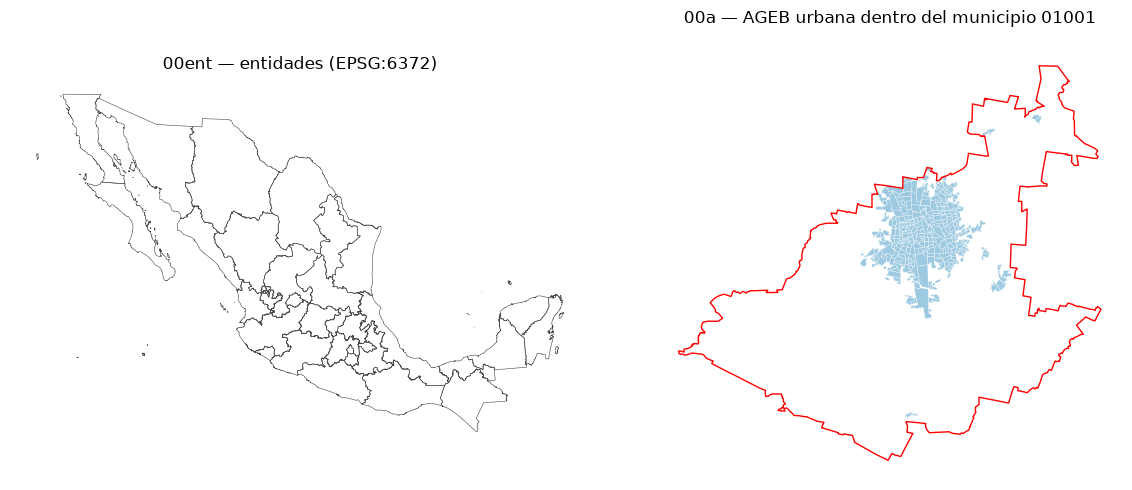

In [8]:
import matplotlib.pyplot as plt

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 5))
ent.boundary.plot(ax=a1, linewidth=0.4, color="#444")
a1.set_title("00ent — entidades (EPSG:6372)")
a1.set_axis_off()

cve_mun = "01001"  # Aguascalientes
mun[mun.CVEGEO == cve_mun].boundary.plot(ax=a2, color="red", linewidth=1)
ageb[ageb.CVEGEO.str.startswith(cve_mun)].plot(ax=a2, facecolor="#9ecae1", edgecolor="white", linewidth=0.2)
a2.set_title(f"00a — AGEB urbana dentro del municipio {cve_mun}")
a2.set_axis_off()
plt.tight_layout()

## 5. Procedencia (`SOURCE.md`)

In [9]:
hoy = datetime.now(timezone.utc).strftime("%Y-%m-%d")
source = f"""# Marco Geoestadístico 2020 (INEGI) — procedencia

- **Producto:** Marco Geoestadístico. Censo de Población y Vivienda 2020 (integrado nacional)
- **Ficha INEGI:** {FICHA}
- **Descarga:** {URL}
- **Fecha de descarga:** {hoy}
- **Tamaño:** {EXPECTED_SIZE} bytes
- **SHA-256:** `{ZIP_SHA256}`
- **CRS de las capas:** EPSG:6372 (México ITRF2008 / Lambert cónica conforme).
  El `.prj` es WKT ESRI sin código de autoridad (`to_epsg()` → None); los
  parámetros coinciden con EPSG:6372, asignarlo explícitamente al leer.
- **Licencia:** Términos de libre uso de la información del INEGI
  (https://www.inegi.org.mx/inegi/terminos.html)

## Extraído del zip

| archivo | capa | registros |
|---|---|---|
| `conjunto_de_datos/00ent.*` | Entidades federativas | {resumen['00ent']} |
| `conjunto_de_datos/00mun.*` | Municipios | {resumen['00mun']} |
| `conjunto_de_datos/00a.*` | AGEB urbana (`Ambito=Urbana`, clave 13) | {resumen['00a_urb']} |
| `conjunto_de_datos/00a.*` | AGEB rural (`Ambito=Rural`, clave 9) | {resumen['00a_rur']} |

Más `catalogos/*.txt` y `catalogos/*.csv`. El resto del zip (localidades `00l`,
puntuales `00lpr`, PDFs) no se extrae; el zip completo se conserva aquí mismo.

Generado por `notebooks/004_INEGI_MGN_download.ipynb`.
"""
(MGN_DIR / "SOURCE.md").write_text(source, encoding="utf-8")
print(source)

# Marco Geoestadístico 2020 (INEGI) — procedencia

- **Producto:** Marco Geoestadístico. Censo de Población y Vivienda 2020 (integrado nacional)
- **Ficha INEGI:** https://www.inegi.org.mx/app/biblioteca/ficha.html?upc=889463807469
- **Descarga:** https://www.inegi.org.mx/contenidos/productos/prod_serv/contenidos/espanol/bvinegi/productos/geografia/marcogeo/889463807469/mg_2020_integrado.zip
- **Fecha de descarga:** 2026-09-02
- **Tamaño:** 257527530 bytes
- **SHA-256:** `98ccee5e796da1e00a3c6fa3d7d821d16b8cc407a16d782f9ce0d072b9dfcac7`
- **CRS de las capas:** EPSG:6372 (México ITRF2008 / Lambert cónica conforme).
  El `.prj` es WKT ESRI sin código de autoridad (`to_epsg()` → None); los
  parámetros coinciden con EPSG:6372, asignarlo explícitamente al leer.
- **Licencia:** Términos de libre uso de la información del INEGI
  (https://www.inegi.org.mx/inegi/terminos.html)

## Extraído del zip

| archivo | capa | registros |
|---|---|---|
| `conjunto_de_datos/00ent.*` | Entidades federati